In [1]:
from roboflow import Roboflow
rf = Roboflow(api_key="VoUouiRQGfiuhUbEQnYb")
project = rf.workspace("my-arena").project("final_inculsion_classification-tqrmh")
version = project.version(1)
dataset = version.download("multiclass")
print("Downloaded multiclass format") 

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to Final_Inculsion_Classification-1 in multiclass:: 100%|██████████| 629/629 [00:00<00:00, 1202.04it/s]

Downloaded multiclass format


In [2]:
import os
import shutil
import pandas as pd

def convert_multilabel_csv_to_folders(dataset_root, output_root):
    """Convert multi-label CSV to folder structure"""
    
    os.makedirs(output_root, exist_ok=True)
    
    for split in ['train', 'valid', 'test']:
        print(f"Processing {split}...")
        
        csv_path = os.path.join(dataset_root, f"{split}/_classes.csv")
        images_dir = os.path.join(dataset_root, split)
        output_split_dir = os.path.join(output_root, split)
        
        # Read CSV
        df = pd.read_csv(csv_path)
        
        # Get all class columns (everything except filename)
        class_columns = df.columns[1:]  # Skip filename column
        
        # Create folders for each class
        for class_name in class_columns:
            os.makedirs(os.path.join(output_split_dir, class_name), exist_ok=True)
        
        # Copy images to class folders based on labels
        for idx, row in df.iterrows():
            filename = row['filename']  # First column
            src = os.path.join(images_dir, filename)
            
            if os.path.exists(src):
                # For each class where label is 1, copy image to that class folder
                for class_name in class_columns:
                    if row[class_name] == 1:  # If this class is present
                        dst = os.path.join(output_split_dir, class_name, filename)
                        shutil.copy2(src, dst)
                        print(f"  ✓ {filename} → {class_name}")
            else:
                print(f"  ⚠️  Missing: {src}")
    
    print("✓ Conversion complete!")

# Use it
convert_multilabel_csv_to_folders(
    dataset_root=".\Final_Inculsion_Classification-1",
    output_root=".\inclusion_dataset_multilabel"
)


Processing train...
  ✓ S-2-500x0041_jpg.rf.359d929adc068d992bafd52df27cd730.jpg → Globular oxide Inclusion
  ✓ S-2-500x0041_jpg.rf.359d929adc068d992bafd52df27cd730.jpg → Silicate Inclusion
  ✓ S-2-500x0041_jpg.rf.359d929adc068d992bafd52df27cd730.jpg → Sulfide Inclusion
  ✓ S-3-1000x-0027_jpg.rf.784909b8c2f5eb64d94356e2d3bb6772.jpg → Globular oxide Inclusion
  ✓ S-2-500x0085_jpg.rf.ac0416cce44b746f6621b5d6b1520b02.jpg → Globular oxide Inclusion
  ✓ S-2-500x0085_jpg.rf.ac0416cce44b746f6621b5d6b1520b02.jpg → Sulfide Inclusion
  ✓ S-3-1000x-0016_jpg.rf.6f2b04d3240e0aa4b689c4381f6e6457.jpg → Globular oxide Inclusion
  ✓ 0-3-200x0026_jpg.rf.8fb74d1d8665f18d719ea1bfdeb18f83.jpg → Alumina Inclusion
  ✓ 0-3-200x0026_jpg.rf.8fb74d1d8665f18d719ea1bfdeb18f83.jpg → Sulfide Inclusion
  ✓ S-2-500x0077_jpg.rf.39cd0297f948f9d85913275bc96558ca.jpg → Alumina Inclusion
  ✓ S-2-500x0077_jpg.rf.39cd0297f948f9d85913275bc96558ca.jpg → Silicate Inclusion
  ✓ S-2-500x0040_jpg.rf.58b233d6626c37105817079b9de3601

In [3]:
# ============================================================================
# STEP 2 - PART 1: Imports and Basic Setup
# ============================================================================

import torch
from torch.utils.data import Dataset, DataLoader
from PIL import Image
import torchvision.transforms as transforms
import os
import numpy as np
import matplotlib.pyplot as plt
import json

print("✓ All imports successful")
print(f"✓ PyTorch version: {torch.__version__}")
print(f"✓ CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"✓ CUDA device: {torch.cuda.get_device_name(0)}")


✓ All imports successful
✓ PyTorch version: 2.9.0+cu126
✓ CUDA available: True
✓ CUDA device: NVIDIA GeForce RTX 3050 Laptop GPU


In [4]:
# ============================================================================
# STEP 2 - PART 2: Define Custom Multi-Label Dataset Class
# ============================================================================

class MultiLabelInclusionDataset(Dataset):
    """
    Custom PyTorch Dataset for multi-label steel inclusion classification.
    
    Images are organized in folders by class. Same image can appear in 
    multiple class folders (since it has multiple labels).
    """
    
    def __init__(self, split_path, class_names, transform=None):
        self.split_path = split_path
        self.class_names = class_names
        self.class_to_idx = {cls: idx for idx, cls in enumerate(class_names)}
        self.transform = transform
        
        # Dictionary to store: image_filename -> [0, 1, 0, 1] (label vector)
        self.image_labels = {}
        
        print(f"\n[INFO] Loading dataset from: {split_path}")
        print(f"[INFO] Classes: {class_names}")
        
        # Scan all class folders and build image-label mapping
        for class_name in class_names:
            class_folder = os.path.join(split_path, class_name)
            
            if not os.path.exists(class_folder):
                print(f"[WARNING] Class folder not found: {class_folder}")
                continue
            
            # Get all images in this class folder
            image_files = os.listdir(class_folder)
            
            for image_file in image_files:
                # Only process image files
                if not image_file.lower().endswith(('.jpg', '.jpeg', '.png', '.bmp')):
                    continue
                
                # Initialize label vector if this is first time seeing this image
                if image_file not in self.image_labels:
                    self.image_labels[image_file] = [0] * len(class_names)
                
                # Set this class to 1 (image has this inclusion type)
                class_idx = self.class_to_idx[class_name]
                self.image_labels[image_file][class_idx] = 1
        
        # Create final list of unique images
        self.image_files = list(self.image_labels.keys())
        
        # Print statistics
        print(f"[INFO] Total unique images loaded: {len(self.image_files)}")
        print("\n[INFO] Class distribution in this split:")
        for class_idx, class_name in enumerate(class_names):
            count = sum(labels[class_idx] for labels in self.image_labels.values())
            percentage = (count / len(self.image_files) * 100) if len(self.image_files) > 0 else 0
            print(f"       {class_name:20s}: {count:3d} images ({percentage:6.2f}%)")
        
        # Print label statistics
        labels_per_image = [sum(labels) for labels in self.image_labels.values()]
        print(f"\n[INFO] Labels per image statistics:")
        print(f"       Min labels: {min(labels_per_image)} (single-label)")
        print(f"       Max labels: {max(labels_per_image)} (multi-label)")
        print(f"       Avg labels: {np.mean(labels_per_image):.2f}")
    
    def __len__(self):
        """Return total number of unique images in this split"""
        return len(self.image_files)
    
    def __getitem__(self, idx):
        """Return one image and its label vector"""
        # Get image filename and labels
        image_file = self.image_files[idx]
        labels = torch.tensor(self.image_labels[image_file], dtype=torch.float32)
        
        # Find the image path (look in all class folders where this image exists)
        image_path = None
        for class_name in self.class_names:
            class_folder = os.path.join(self.split_path, class_name)
            candidate_path = os.path.join(class_folder, image_file)
            if os.path.exists(candidate_path):
                image_path = candidate_path
                break
        
        # If image not found, raise error
        if image_path is None:
            raise FileNotFoundError(f"Image {image_file} not found in any class folder")
        
        # Load and convert image to RGB
        image = Image.open(image_path).convert('RGB')
        
        # Apply transformations
        if self.transform:
            image = self.transform(image)
        
        return image, labels

print("✓ MultiLabelInclusionDataset class defined successfully")


✓ MultiLabelInclusionDataset class defined successfully


In [5]:
# ============================================================================
# STEP 2 - PART 3: Define Transformation Pipelines
# ============================================================================

print("\n" + "="*70)
print("DEFINING TRANSFORMATION PIPELINES")
print("="*70)

# Training transforms (with augmentation)
train_transforms = transforms.Compose([
    # Resize to fixed size
    transforms.Resize((312, 312)),
    
    # Geometric augmentations
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.5),
    transforms.RandomRotation(degrees=25),
    
    # Color augmentations
    transforms.ColorJitter(
        brightness=0.2,
        contrast=0.2,
        saturation=0.2,
        hue=0.1
    ),
    
    # Blur
    transforms.GaussianBlur(kernel_size=3, sigma=(0.1, 2.0)),
    
    # Convert to tensor
    transforms.ToTensor(),
    
    # Normalize
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    ),
    
    # Random erasing
    transforms.RandomErasing(p=0.2, scale=(0.02, 0.1))
])

# Validation and Test transforms (NO augmentation)
val_test_transforms = transforms.Compose([
    transforms.Resize((312, 312)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

print("\n[INFO] Training transforms:")
print("  - Resize to 312x312")
print("  - Random horizontal/vertical flip")
print("  - Random rotation (±25°)")
print("  - Color jitter (brightness, contrast, saturation, hue)")
print("  - Gaussian blur")
print("  - Normalize with ImageNet statistics")
print("  - Random erasing")

print("\n[INFO] Validation/Test transforms:")
print("  - Resize to 312x312")
print("  - Normalize with ImageNet statistics")
print("  (NO augmentation)")

print("\n✓ Transform pipelines created")



DEFINING TRANSFORMATION PIPELINES

[INFO] Training transforms:
  - Resize to 312x312
  - Random horizontal/vertical flip
  - Random rotation (±25°)
  - Color jitter (brightness, contrast, saturation, hue)
  - Gaussian blur
  - Normalize with ImageNet statistics
  - Random erasing

[INFO] Validation/Test transforms:
  - Resize to 312x312
  - Normalize with ImageNet statistics
  (NO augmentation)

✓ Transform pipelines created


In [6]:
# ============================================================================
# STEP 2 - PART 4: Create Datasets
# ============================================================================

print("\n" + "="*70)
print("CREATING DATASETS")
print("="*70)

# Define paths and class names
DATASET_ROOT = "./inclusion_dataset_multilabel"
CLASS_NAMES = ['Sulfide Inclusion', 'Alumina Inclusion', 'Silicate Inclusion', 'Globular oxide Inclusion']

# Create dataset for each split
train_dataset = MultiLabelInclusionDataset(
    split_path=os.path.join(DATASET_ROOT, 'train'),
    class_names=CLASS_NAMES,
    transform=train_transforms
)

val_dataset = MultiLabelInclusionDataset(
    split_path=os.path.join(DATASET_ROOT, 'valid'),
    class_names=CLASS_NAMES,
    transform=val_test_transforms
)

test_dataset = MultiLabelInclusionDataset(
    split_path=os.path.join(DATASET_ROOT, 'test'),
    class_names=CLASS_NAMES,
    transform=val_test_transforms
)

print("\n✓ All datasets created successfully")



CREATING DATASETS

[INFO] Loading dataset from: ./inclusion_dataset_multilabel\train
[INFO] Classes: ['Sulfide Inclusion', 'Alumina Inclusion', 'Silicate Inclusion', 'Globular oxide Inclusion']
[INFO] Total unique images loaded: 558

[INFO] Class distribution in this split:
       Sulfide Inclusion   :  99 images ( 17.74%)
       Alumina Inclusion   : 222 images ( 39.78%)
       Silicate Inclusion  : 165 images ( 29.57%)
       Globular oxide Inclusion: 231 images ( 41.40%)

[INFO] Labels per image statistics:
       Min labels: 1 (single-label)
       Max labels: 3 (multi-label)
       Avg labels: 1.28

[INFO] Loading dataset from: ./inclusion_dataset_multilabel\valid
[INFO] Classes: ['Sulfide Inclusion', 'Alumina Inclusion', 'Silicate Inclusion', 'Globular oxide Inclusion']
[INFO] Total unique images loaded: 39

[INFO] Class distribution in this split:
       Sulfide Inclusion   :   9 images ( 23.08%)
       Alumina Inclusion   :  15 images ( 38.46%)
       Silicate Inclusion  :   7

In [7]:
# ============================================================================
# STEP 2 - PART 5: Create DataLoaders (GPU OPTIMIZED)
# ============================================================================

print("\n" + "="*70)
print("CREATING DATALOADERS")
print("="*70)

BATCH_SIZE = 32

# Use pin_memory=True if using GPU for faster data transfer
use_pin_memory = torch.cuda.is_available()

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0,  # Still 0 on Windows
    pin_memory=use_pin_memory,  # True if GPU available
    drop_last=False
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=use_pin_memory,
    drop_last=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=use_pin_memory,
    drop_last=False
)

print(f"\n[INFO] DataLoaders created (GPU optimized):")
print(f"       pin_memory: {use_pin_memory} (GPU available)")
print(f"       Train: {len(train_loader)} batches")
print(f"       Val:   {len(val_loader)} batches")
print(f"       Test:  {len(test_loader)} batches")

print("\n✓ All dataloaders ready")



CREATING DATALOADERS

[INFO] DataLoaders created (GPU optimized):
       pin_memory: True (GPU available)
       Train: 18 batches
       Val:   2 batches
       Test:  1 batches

✓ All dataloaders ready


In [8]:
# ============================================================================
# STEP 2 - PART 6: Verify Data Loading - Test Single Batch
# ============================================================================

print("\n" + "="*70)
print("VERIFYING DATA LOADING - SINGLE BATCH TEST")
print("="*70)

# Get one batch from training dataloader
images, labels = next(iter(train_loader))

print(f"\n[INFO] Single batch loaded successfully!")
print(f"       Images shape: {images.shape}")
print(f"       Images dtype: {images.dtype}")
print(f"       Labels shape: {labels.shape}")
print(f"       Labels dtype: {labels.dtype}")

print(f"\n[INFO] First 5 samples from batch:")
print(f"       {'Image Index':<12} {'Image Size':<15} {'Labels (S,A,Si,G)':<20}")
print(f"       {'-'*47}")

for i in range(min(5, len(images))):
    label_str = str([int(l) for l in labels[i].tolist()])
    print(f"       {i:<12} {str(images[i].shape):<15} {label_str:<20}")

# Print label statistics
print(f"\n[INFO] Label statistics for this batch:")
labels_per_sample = labels.sum(dim=1)
print(f"       Min labels per image: {int(labels_per_sample.min())}")
print(f"       Max labels per image: {int(labels_per_sample.max())}")
print(f"       Avg labels per image: {labels_per_sample.mean():.2f}")

# Class distribution in batch
print(f"\n[INFO] Class distribution in this batch:")
class_counts = labels.sum(dim=0)
for class_idx, class_name in enumerate(CLASS_NAMES):
    count = int(class_counts[class_idx].item())
    print(f"       {class_name:20s}: {count:3d} occurrences")

print("\n✓ Single batch test passed!")



VERIFYING DATA LOADING - SINGLE BATCH TEST

[INFO] Single batch loaded successfully!
       Images shape: torch.Size([32, 3, 312, 312])
       Images dtype: torch.float32
       Labels shape: torch.Size([32, 4])
       Labels dtype: torch.float32

[INFO] First 5 samples from batch:
       Image Index  Image Size      Labels (S,A,Si,G)   
       -----------------------------------------------
       0            torch.Size([3, 312, 312]) [0, 0, 1, 0]        
       1            torch.Size([3, 312, 312]) [0, 0, 0, 1]        
       2            torch.Size([3, 312, 312]) [1, 0, 0, 0]        
       3            torch.Size([3, 312, 312]) [0, 0, 0, 1]        
       4            torch.Size([3, 312, 312]) [0, 0, 0, 1]        

[INFO] Label statistics for this batch:
       Min labels per image: 1
       Max labels per image: 2
       Avg labels per image: 1.12

[INFO] Class distribution in this batch:
       Sulfide Inclusion   :   4 occurrences
       Alumina Inclusion   :  13 occurrences



VISUALIZING SAMPLE IMAGES

✓ Visualization saved to: ./sample_images_verification.png


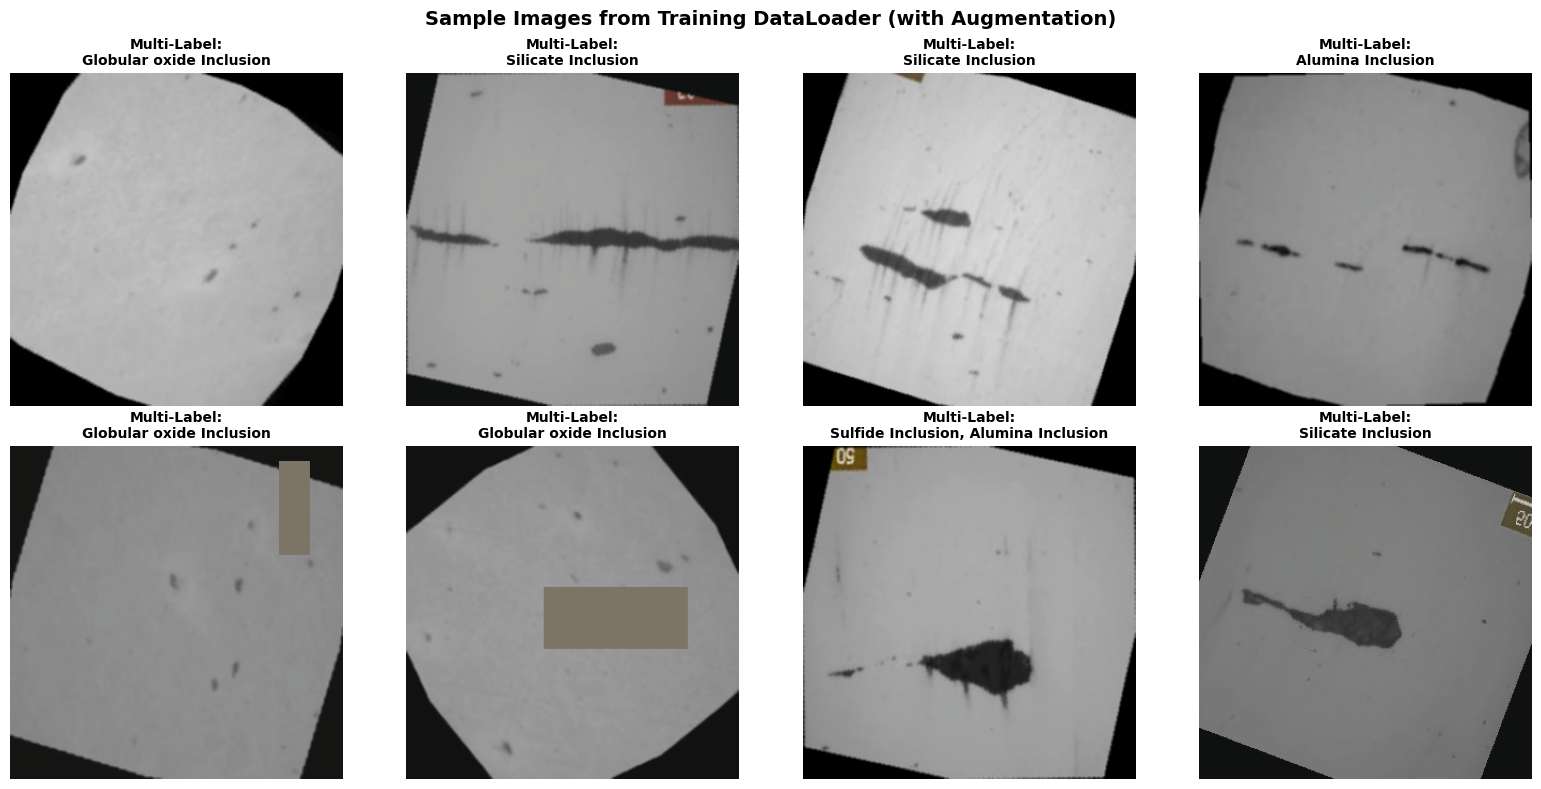

✓ Sample images displayed


In [9]:
# ============================================================================
# STEP 2 - PART 7: Visualize Sample Images
# ============================================================================

print("\n" + "="*70)
print("VISUALIZING SAMPLE IMAGES")
print("="*70)

def denormalize(tensor):
    """Convert normalized tensor back to [0, 1] range for visualization"""
    inv_normalize = transforms.Compose([
        transforms.Normalize(
            mean=[-0.485/0.229, -0.456/0.224, -0.406/0.225],
            std=[1/0.229, 1/0.224, 1/0.225]
        )
    ])
    return inv_normalize(tensor)

# Create visualization
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

# Get batch from training loader
images_aug, labels_aug = next(iter(train_loader))

for idx in range(min(8, len(images_aug))):
    ax = axes[idx]
    
    # Denormalize image
    img = denormalize(images_aug[idx])
    img_np = img.numpy().transpose(1, 2, 0)
    img_np = np.clip(img_np, 0, 1)
    
    # Get labels
    label_vector = labels_aug[idx].numpy()
    present_classes = [CLASS_NAMES[i] for i in range(len(CLASS_NAMES)) 
                       if label_vector[i] == 1]
    
    # Plot
    ax.imshow(img_np)
    title = "Multi-Label:\n" + ", ".join(present_classes) if present_classes else "No labels"
    ax.set_title(title, fontsize=10, fontweight='bold')
    ax.axis('off')

plt.suptitle("Sample Images from Training DataLoader (with Augmentation)", 
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('./sample_images_verification.png', dpi=100, bbox_inches='tight')
print(f"\n✓ Visualization saved to: ./sample_images_verification.png")
plt.show()

print("✓ Sample images displayed")



VERIFYING AUGMENTATION - LOADING SAME IMAGE 5 TIMES

[INFO] Loading same image 5 times with different augmentations:
       Labels: ['Sulfide Inclusion', 'Silicate Inclusion', 'Globular oxide Inclusion']

✓ Augmentation verification saved to: ./augmentation_verification.png


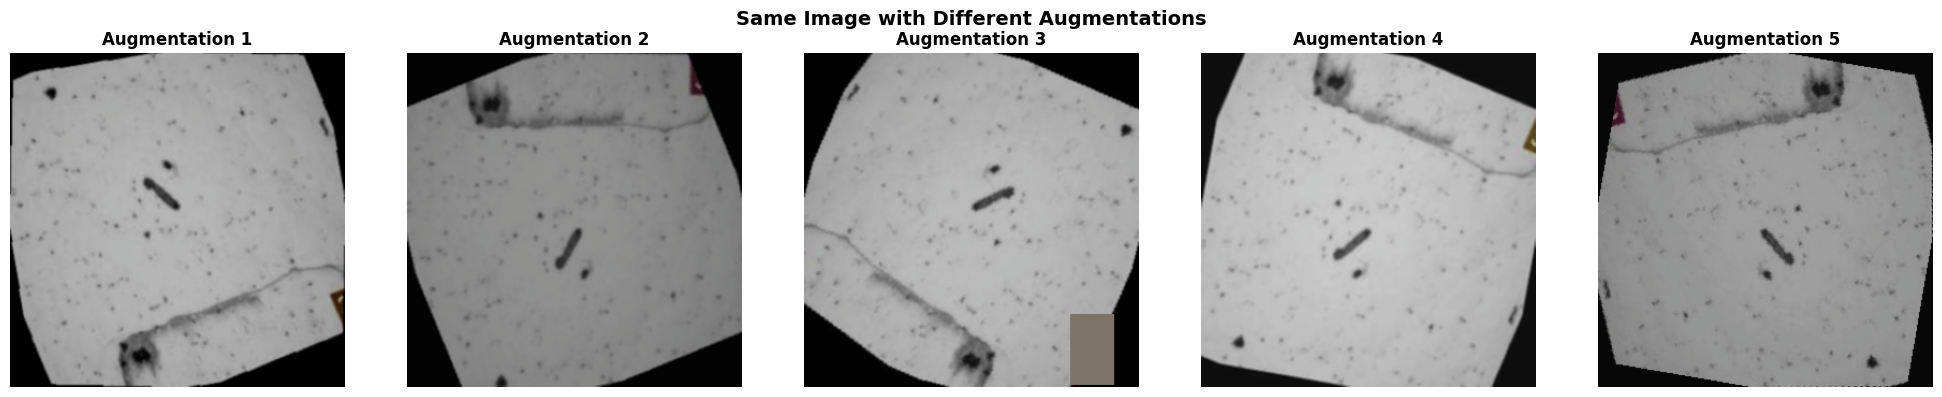

✓ Augmentation verification complete


In [10]:
# ============================================================================
# STEP 2 - PART 8: Verify Augmentation is Working
# ============================================================================

print("\n" + "="*70)
print("VERIFYING AUGMENTATION - LOADING SAME IMAGE 5 TIMES")
print("="*70)

# Load the same image 5 times to see augmentation differences
fig, axes = plt.subplots(1, 5, figsize=(20, 4))

# Get first image from dataset
image, labels = train_dataset[0]

print(f"\n[INFO] Loading same image 5 times with different augmentations:")
print(f"       Labels: {[CLASS_NAMES[i] for i in range(len(CLASS_NAMES)) if labels[i] == 1]}")

for aug_idx in range(5):
    # Load same image (index 0) again - will get different augmentation each time
    image_aug, _ = train_dataset[0]
    
    # Denormalize
    img_vis = denormalize(image_aug)
    img_vis_np = img_vis.numpy().transpose(1, 2, 0)
    img_vis_np = np.clip(img_vis_np, 0, 1)
    
    # Plot
    axes[aug_idx].imshow(img_vis_np)
    axes[aug_idx].set_title(f"Augmentation {aug_idx + 1}", fontsize=12, fontweight='bold')
    axes[aug_idx].axis('off')

plt.suptitle("Same Image with Different Augmentations", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('./augmentation_verification.png', dpi=100, bbox_inches='tight')
print(f"\n✓ Augmentation verification saved to: ./augmentation_verification.png")
plt.show()

print("✓ Augmentation verification complete")


In [11]:
# ============================================================================
# STEP 2 - PART 9: Summary and Save Metadata
# ============================================================================

print("\n" + "="*70)
print("SUMMARY - DATA LOADING VERIFICATION COMPLETE")
print("="*70)

print(f"\n✓ Custom Dataset Class: MultiLabelInclusionDataset")
print(f"  - Handles multi-label loading correctly")
print(f"  - Returns image tensors and binary label vectors")

print(f"\n✓ Transformation Pipelines:")
print(f"  - Training: Geometric + color augmentations")
print(f"  - Val/Test: Only normalization (no augmentation)")

print(f"\n✓ Datasets Created:")
print(f"  - Train: {len(train_dataset)} unique images")
print(f"  - Val:   {len(val_dataset)} unique images")
print(f"  - Test:  {len(test_dataset)} unique images")
print(f"  - Total: {len(train_dataset) + len(val_dataset) + len(test_dataset)} images")

print(f"\n✓ DataLoaders Ready:")
print(f"  - Batch size: {BATCH_SIZE}")
print(f"  - Train batches: {len(train_loader)}")
print(f"  - Val batches: {len(val_loader)}")
print(f"  - Test batches: {len(test_loader)}")

print(f"\n✓ Verifications Passed:")
print(f"  - ✓ Single batch loads successfully")
print(f"  - ✓ Image shapes correct: {images.shape}")
print(f"  - ✓ Label shapes correct: {labels.shape}")
print(f"  - ✓ Multi-label loading works")
print(f"  - ✓ Dynamic augmentation verified")
print(f"  - ✓ Visualizations saved")

# Save metadata
metadata = {
    'dataset_root': DATASET_ROOT,
    'class_names': CLASS_NAMES,
    'num_classes': len(CLASS_NAMES),
    'train_size': len(train_dataset),
    'val_size': len(val_dataset),
    'test_size': len(test_dataset),
    'batch_size': BATCH_SIZE,
    'image_size': 312,
    'normalization': {
        'mean': [0.485, 0.456, 0.406],
        'std': [0.229, 0.224, 0.225]
    }
}

with open('./dataset_metadata.json', 'w') as f:
    json.dump(metadata, f, indent=4)

print(f"\n✓ Metadata saved to: ./dataset_metadata.json")

print(f"\n{'='*70}")
print(f"STEP 2 COMPLETE - Ready for Step 3: Model Training")
print(f"Use these objects in training:")
print(f"  - train_loader")
print(f"  - val_loader")
print(f"  - test_loader")
print(f"  - CLASS_NAMES")
print(f"  - BATCH_SIZE")
print(f"{'='*70}\n")



SUMMARY - DATA LOADING VERIFICATION COMPLETE

✓ Custom Dataset Class: MultiLabelInclusionDataset
  - Handles multi-label loading correctly
  - Returns image tensors and binary label vectors

✓ Transformation Pipelines:
  - Training: Geometric + color augmentations
  - Val/Test: Only normalization (no augmentation)

✓ Datasets Created:
  - Train: 558 unique images
  - Val:   39 unique images
  - Test:  24 unique images
  - Total: 621 images

✓ DataLoaders Ready:
  - Batch size: 32
  - Train batches: 18
  - Val batches: 2
  - Test batches: 1

✓ Verifications Passed:
  - ✓ Single batch loads successfully
  - ✓ Image shapes correct: torch.Size([32, 3, 312, 312])
  - ✓ Label shapes correct: torch.Size([4])
  - ✓ Multi-label loading works
  - ✓ Dynamic augmentation verified
  - ✓ Visualizations saved

✓ Metadata saved to: ./dataset_metadata.json

STEP 2 COMPLETE - Ready for Step 3: Model Training
Use these objects in training:
  - train_loader
  - val_loader
  - test_loader
  - CLASS_NAMES


In [12]:
# ============================================================================
# STEP 3 - PART 1: Imports and Device Setup
# ============================================================================

import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import models
import numpy as np
import matplotlib.pyplot as plt
import json
import os
from datetime import datetime
from tqdm import tqdm

print("✓ All imports successful")

# Setup device (CPU or CUDA)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"✓ Using device: {device}")

if torch.cuda.is_available():
    print(f"  GPU: {torch.cuda.get_device_name(0)}")
    print(f"  CUDA version: {torch.version.cuda}")


✓ All imports successful
✓ Using device: cuda
  GPU: NVIDIA GeForce RTX 3050 Laptop GPU
  CUDA version: 12.6


In [13]:
# ============================================================================
# STEP 3 - PART 2: Define Model Architecture (GPU OPTIMIZED)
# ============================================================================

class MultiLabelClassificationModel(nn.Module):
    """Multi-label classification model using transfer learning."""
    
    def __init__(self, num_classes=4, pretrained=True):
        super(MultiLabelClassificationModel, self).__init__()
        
        self.num_classes = num_classes
        
        print(f"\n[INFO] Loading pre-trained ResNet50...")
        resnet50 = models.resnet50(pretrained=pretrained)
        
        self.features = nn.Sequential(*list(resnet50.children())[:-1])
        
        in_features = resnet50.fc.in_features
        print(f"[INFO] ResNet50 output features: {in_features}")
        
        self.classifier = nn.Sequential(
            nn.Dropout(p=0.5),
            nn.Linear(in_features, 512),
            nn.ReLU(inplace=True),
            nn.Dropout(p=0.3),
            nn.Linear(512, 128),
            nn.ReLU(inplace=True),
            nn.Linear(128, num_classes),
        )
        
        print(f"[INFO] Model created with {num_classes} output classes")
    
    def forward(self, x):
        features = self.features(x)
        features = features.view(features.size(0), -1)
        logits = self.classifier(features)
        return logits

# Create model
NUM_CLASSES = 4
model = MultiLabelClassificationModel(num_classes=NUM_CLASSES, pretrained=True)

# ✓ CRITICAL: Move model to GPU/device
model = model.to(device)

print(f"\n✓ Model created and moved to {device}")
print(f"  Model is on GPU: {next(model.parameters()).is_cuda}")

# Count parameters
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"\nTotal parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")



[INFO] Loading pre-trained ResNet50...


The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.


[INFO] ResNet50 output features: 2048
[INFO] Model created with 4 output classes

✓ Model created and moved to cuda
  Model is on GPU: True

Total parameters: 24,623,300
Trainable parameters: 24,623,300


In [14]:
# ============================================================================
# STEP 3 - PART 3: Define Loss Function and Optimizer (FIXED)
# ============================================================================

print("\n" + "="*70)
print("SETTING UP LOSS AND OPTIMIZER")
print("="*70)

# Loss function for multi-label classification
# BCEWithLogitsLoss combines Sigmoid + BCELoss for numerical stability
criterion = nn.BCEWithLogitsLoss()
print(f"\n[INFO] Loss function: BCEWithLogitsLoss")
print(f"       (Combines Sigmoid + BCE for numerical stability)")
print(f"       (Treats each class as independent binary classification)")

# Optimizer: Adam with learning rate
learning_rate = 0.001
optimizer = optim.Adam(model.parameters(), lr=learning_rate, weight_decay=1e-4)
print(f"\n[INFO] Optimizer: Adam")
print(f"       Learning rate: {learning_rate}")
print(f"       Weight decay (L2 regularization): 1e-4")

# Learning rate scheduler: reduce LR if validation loss plateaus
# FIXED: Removed 'verbose' parameter (not supported in newer PyTorch versions)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    factor=0.5,
    patience=5
    # verbose parameter removed - not supported in newer PyTorch
)
print(f"\n[INFO] Learning rate scheduler: ReduceLROnPlateau")
print(f"       Will reduce LR by 0.5 if val loss plateaus for 5 epochs")

print(f"\n✓ Loss function and optimizer configured")



SETTING UP LOSS AND OPTIMIZER

[INFO] Loss function: BCEWithLogitsLoss
       (Combines Sigmoid + BCE for numerical stability)
       (Treats each class as independent binary classification)

[INFO] Optimizer: Adam
       Learning rate: 0.001
       Weight decay (L2 regularization): 1e-4

[INFO] Learning rate scheduler: ReduceLROnPlateau
       Will reduce LR by 0.5 if val loss plateaus for 5 epochs

✓ Loss function and optimizer configured


In [15]:
# ============================================================================
# STEP 3 - PART 4: Define Training and Validation Functions (FIXED)
# ============================================================================

def train_epoch(model, train_loader, criterion, optimizer, device, epoch, num_epochs):
    """
    Train for one epoch.
    
    Args:
        model: PyTorch model
        train_loader: Training dataloader
        criterion: Loss function (BCEWithLogitsLoss)
        optimizer: Optimizer (Adam)
        device: CPU or CUDA device
        epoch: Current epoch number
        num_epochs: Total number of epochs
    
    Returns:
        train_loss: Average training loss for this epoch
    """
    model.train()  # Set to training mode (dropout, batch norm active)
    
    total_loss = 0.0
    num_batches = 0
    
    # Progress bar
    pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs} [TRAIN]")
    
    for images, labels in pbar:
        # Move data to device
        images = images.to(device)
        labels = labels.to(device)  # Shape: (batch_size, num_classes)
        
        # Forward pass
        outputs = model(images)  # Shape: (batch_size, num_classes)
        
        # Calculate loss
        # labels are [0, 1, 1, 0] format
        # outputs are raw logits (sigmoid applied inside BCEWithLogitsLoss)
        loss = criterion(outputs, labels)
        
        # Backward pass
        optimizer.zero_grad()  # Clear old gradients
        loss.backward()  # Calculate gradients
        optimizer.step()  # Update weights
        
        # Accumulate loss
        total_loss += loss.item()
        num_batches += 1
        
        # Update progress bar (FIXED: Proper dictionary formatting)
        pbar.set_postfix({'loss': f'{loss.item():.4f}'})
    
    avg_loss = total_loss / num_batches
    return avg_loss


def validate_epoch(model, val_loader, criterion, device, epoch, num_epochs):
    """
    Validate for one epoch.
    
    Args:
        model: PyTorch model
        val_loader: Validation dataloader
        criterion: Loss function
        device: CPU or CUDA device
        epoch: Current epoch number
        num_epochs: Total number of epochs
    
    Returns:
        val_loss: Average validation loss
        metrics: Dictionary with validation metrics
    """
    model.eval()  # Set to evaluation mode (dropout off, batch norm frozen)
    
    total_loss = 0.0
    num_batches = 0
    
    all_predictions = []
    all_labels = []
    
    # No gradients needed for validation
    with torch.no_grad():
        pbar = tqdm(val_loader, desc=f"Epoch {epoch+1}/{num_epochs} [VAL]")
        
        for images, labels in pbar:
            # Move to device
            images = images.to(device)
            labels = labels.to(device)
            
            # Forward pass
            outputs = model(images)
            
            # Calculate loss
            loss = criterion(outputs, labels)
            total_loss += loss.item()
            num_batches += 1
            
            # Store predictions and labels for metrics
            all_predictions.append(torch.sigmoid(outputs).cpu())  # Apply sigmoid for probabilities
            all_labels.append(labels.cpu())
            
            # Update progress bar (FIXED: Proper dictionary formatting)
            pbar.set_postfix({'loss': f'{loss.item():.4f}'})
    
    avg_loss = total_loss / num_batches
    
    # Concatenate all batches
    all_predictions = torch.cat(all_predictions, dim=0)  # (total_samples, num_classes)
    all_labels = torch.cat(all_labels, dim=0)
    
    # Calculate metrics
    # For multi-label, use threshold of 0.5 on probabilities
    pred_binary = (all_predictions > 0.5).float()
    
    # Calculate average metrics across classes
    tp = (pred_binary * all_labels).sum()  # True positives
    fp = (pred_binary * (1 - all_labels)).sum()  # False positives
    fn = ((1 - pred_binary) * all_labels).sum()  # False negatives
    
    precision = tp / (tp + fp + 1e-8)
    recall = tp / (tp + fn + 1e-8)
    f1_score = 2 * (precision * recall) / (precision + recall + 1e-8)
    
    metrics = {
        'loss': avg_loss,
        'precision': precision.item(),
        'recall': recall.item(),
        'f1_score': f1_score.item()
    }
    
    return avg_loss, metrics

print("✓ Training and validation functions defined")


✓ Training and validation functions defined


In [16]:
import torch

print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")

if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"CUDA version: {torch.version.cuda}")
    print(f"GPU Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")
else:
    print("⚠️  GPU not available - will use CPU (slow!)")


PyTorch version: 2.9.0+cu126
CUDA available: True
GPU: NVIDIA GeForce RTX 3050 Laptop GPU
CUDA version: 12.6
GPU Memory: 4.29 GB


In [17]:
# ============================================================================
# STEP 3 - PART 5: Complete Training Loop (GPU OPTIMIZED)
# ============================================================================

print("\n" + "="*70)
print("PRE-TRAINING CHECKS")
print("="*70)

# Verify GPU setup
print(f"\n[INFO] Device: {device}")
print(f"[INFO] Model on device: {next(model.parameters()).device}")
print(f"[INFO] Model on GPU: {next(model.parameters()).is_cuda}")

if torch.cuda.is_available():
    print(f"[INFO] GPU Memory Available: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")
    # Clear cache before training
    torch.cuda.empty_cache()
    print("[INFO] GPU cache cleared")
else:
    print("[WARNING] GPU not available - training on CPU (will be slow)")

print("\n" + "="*70)
print("STARTING TRAINING")
print("="*70)

# Training parameters
NUM_EPOCHS = 30
CHECKPOINT_DIR = "./checkpoints"
os.makedirs(CHECKPOINT_DIR, exist_ok=True)

# Track metrics
history = {
    'train_loss': [],
    'val_loss': [],
    'val_precision': [],
    'val_recall': [],
    'val_f1': [],
    'learning_rates': [],
    'batch_times': []
}

best_val_loss = float('inf')
best_epoch = 0
patience = 10
patience_counter = 0

print(f"\nTraining Configuration:")
print(f"  Total Epochs: {NUM_EPOCHS}")
print(f"  Device: {device}")
print(f"  Checkpoint directory: {CHECKPOINT_DIR}")
print(f"  Batch size: {BATCH_SIZE}")
print(f"  Learning rate: {learning_rate}")

import time

for epoch in range(NUM_EPOCHS):
    epoch_start_time = time.time()
    
    print(f"\n{'='*70}")
    print(f"EPOCH {epoch+1}/{NUM_EPOCHS}")
    print(f"{'='*70}")
    
    # ========== TRAINING ==========
    model.train()  # Set to training mode
    
    train_loss = 0.0
    num_batches = 0
    batch_times = []
    
    pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{NUM_EPOCHS} [TRAIN]")
    
    for batch_idx, (images, labels) in enumerate(pbar):
        batch_start = time.time()
        
        # ✓ CRITICAL: Move data to GPU
        images = images.to(device)
        labels = labels.to(device)
        
        # Forward pass
        outputs = model(images)
        
        # Calculate loss
        loss = criterion(outputs, labels)
        
        # Backward pass
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        # Record metrics
        train_loss += loss.item()
        num_batches += 1
        
        batch_time = time.time() - batch_start
        batch_times.append(batch_time)
        
        # Update progress bar with loss
        pbar.set_postfix({'loss': f'{loss.item():.4f}'})
    
    avg_train_loss = train_loss / num_batches
    avg_batch_time = np.mean(batch_times)
    
    # ========== VALIDATION ==========
    model.eval()  # Set to evaluation mode
    
    val_loss = 0.0
    num_val_batches = 0
    all_predictions = []
    all_labels = []
    
    with torch.no_grad():  # No gradients needed
        pbar = tqdm(val_loader, desc=f"Epoch {epoch+1}/{NUM_EPOCHS} [VAL]")
        
        for images, labels in pbar:
            # ✓ Move data to GPU
            images = images.to(device)
            labels = labels.to(device)
            
            # Forward pass
            outputs = model(images)
            
            # Calculate loss
            loss = criterion(outputs, labels)
            val_loss += loss.item()
            num_val_batches += 1
            
            # Store predictions and labels
            all_predictions.append(torch.sigmoid(outputs).cpu())
            all_labels.append(labels.cpu())
            
            pbar.set_postfix({'loss': f'{loss.item():.4f}'})
    
    avg_val_loss = val_loss / num_val_batches
    
    # Calculate validation metrics
    all_predictions = torch.cat(all_predictions, dim=0)
    all_labels = torch.cat(all_labels, dim=0)
    
    pred_binary = (all_predictions > 0.5).float()
    
    tp = (pred_binary * all_labels).sum()
    fp = (pred_binary * (1 - all_labels)).sum()
    fn = ((1 - pred_binary) * all_labels).sum()
    
    precision = tp / (tp + fp + 1e-8)
    recall = tp / (tp + fn + 1e-8)
    f1_score = 2 * (precision * recall) / (precision + recall + 1e-8)
    
    val_metrics = {
        'precision': precision.item(),
        'recall': recall.item(),
        'f1_score': f1_score.item()
    }
    
    # ========== RECORD METRICS ==========
    history['train_loss'].append(avg_train_loss)
    history['val_loss'].append(avg_val_loss)
    history['val_precision'].append(val_metrics['precision'])
    history['val_recall'].append(val_metrics['recall'])
    history['val_f1'].append(val_metrics['f1_score'])
    history['learning_rates'].append(optimizer.param_groups[0]['lr'])
    history['batch_times'].append(avg_batch_time)
    
    # ========== PRINT SUMMARY ==========
    epoch_time = time.time() - epoch_start_time
    
    print(f"\n[EPOCH SUMMARY]")
    print(f"  Train Loss:     {avg_train_loss:.6f}")
    print(f"  Val Loss:       {avg_val_loss:.6f}")
    print(f"  Val Precision:  {val_metrics['precision']:.4f}")
    print(f"  Val Recall:     {val_metrics['recall']:.4f}")
    print(f"  Val F1 Score:   {val_metrics['f1_score']:.4f}")
    print(f"  Learning Rate:  {optimizer.param_groups[0]['lr']:.6f}")
    print(f"  Avg Batch Time: {avg_batch_time:.4f}s")
    print(f"  Epoch Time:     {epoch_time:.2f}s")
    
    # ========== LEARNING RATE SCHEDULING ==========
    scheduler.step(avg_val_loss)
    
    # ========== SAVE BEST MODEL ==========
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        best_epoch = epoch
        patience_counter = 0
        
        checkpoint_path = os.path.join(CHECKPOINT_DIR, 'best_model.pth')
        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'val_loss': avg_val_loss,
            'val_metrics': val_metrics
        }, checkpoint_path)
        print(f"  ✓ Best model saved")
    else:
        patience_counter += 1
        print(f"  No improvement: {patience_counter}/{patience} epochs")
    
    # ========== EARLY STOPPING ==========
    if patience_counter >= patience:
        print(f"\n[EARLY STOPPING]")
        print(f"No improvement for {patience} epochs")
        print(f"Best validation loss: {best_val_loss:.6f} (Epoch {best_epoch+1})")
        break

# ========== TRAINING COMPLETE ==========
print(f"\n{'='*70}")
print(f"TRAINING COMPLETE")
print(f"{'='*70}")
print(f"Total epochs trained: {len(history['train_loss'])}")
print(f"Best epoch: {best_epoch+1}")
print(f"Best validation loss: {best_val_loss:.6f}")
print(f"Final validation F1 score: {history['val_f1'][-1]:.4f}")

# Save final checkpoint
final_checkpoint = os.path.join(CHECKPOINT_DIR, 'final_model.pth')
torch.save(model.state_dict(), final_checkpoint)
print(f"Final model saved to: {final_checkpoint}")

# Save training history
history_path = os.path.join(CHECKPOINT_DIR, 'training_history.json')
with open(history_path, 'w') as f:
    json.dump(history, f, indent=4)
print(f"Training history saved to: {history_path}")

# Calculate total training time
if torch.cuda.is_available():
    print(f"\n✓ Training completed on GPU")
else:
    print(f"\n⚠️  Training completed on CPU (consider using GPU for faster training)")

print("\n✓ Training loop complete - Ready for Step 3 Part 6 (Load Best Model)")



PRE-TRAINING CHECKS

[INFO] Device: cuda
[INFO] Model on device: cuda:0
[INFO] Model on GPU: True
[INFO] GPU Memory Available: 4.29 GB
[INFO] GPU cache cleared

STARTING TRAINING

Training Configuration:
  Total Epochs: 30
  Device: cuda
  Checkpoint directory: ./checkpoints
  Batch size: 32
  Learning rate: 0.001

EPOCH 1/30


Epoch 1/30 [VAL]: 100%|██████████| 2/2 [00:01<00:00,  1.04it/s, loss=0.3737]



[EPOCH SUMMARY]
  Train Loss:     0.593525
  Val Loss:       0.804143
  Val Precision:  0.8750
  Val Recall:     0.1429
  Val F1 Score:   0.2456
  Learning Rate:  0.001000
  Avg Batch Time: 4.4129s
  Epoch Time:     89.72s
  ✓ Best model saved

EPOCH 2/30


Epoch 2/30 [VAL]: 100%|██████████| 2/2 [00:01<00:00,  1.31it/s, loss=0.0070]



[EPOCH SUMMARY]
  Train Loss:     0.544957
  Val Loss:       0.479060
  Val Precision:  0.7000
  Val Recall:     0.2857
  Val F1 Score:   0.4058
  Learning Rate:  0.001000
  Avg Batch Time: 4.2659s
  Epoch Time:     84.61s
  ✓ Best model saved

EPOCH 3/30


...


[EPOCH SUMMARY]
  Train Loss:     0.357844
  Val Loss:       0.319346
  Val Precision:  0.6429
  Val Recall:     0.5510
  Val F1 Score:   0.5934
  Learning Rate:  0.000500
  Avg Batch Time: 4.0797s
  Epoch Time:     81.08s
  No improvement: 6/10 epochs

EPOCH 29/30


Epoch 29/30 [VAL]: 100%|██████████| 2/2 [00:01<00:00,  1.23it/s, loss=0.0412]



[EPOCH SUMMARY]
  Train Loss:     0.314919
  Val Loss:       0.239853
  Val Precision:  0.7442
  Val Recall:     0.6531
  Val F1 Score:   0.6957
  Learning Rate:  0.000250
  Avg Batch Time: 4.1862s
  Epoch Time:     83.25s
  No improvement: 7/10 epochs

EPOCH 30/30


Epoch 30/30 [VAL]: 100%|██████████| 2/2 [00:01<00:00,  1.29it/s, loss=0.0122]



[EPOCH SUMMARY]
  Train Loss:     0.305357
  Val Loss:       0.233671
  Val Precision:  0.7174
  Val Recall:     0.6735
  Val F1 Score:   0.6947
  Learning Rate:  0.000250
  Avg Batch Time: 4.1805s
  Epoch Time:     82.62s
  ✓ Best model saved

TRAINING COMPLETE
Total epochs trained: 30
Best epoch: 30
Best validation loss: 0.233671
Final validation F1 score: 0.6947
Final model saved to: ./checkpoints\final_model.pth
Training history saved to: ./checkpoints\training_history.json

✓ Training completed on GPU

✓ Training loop complete - Ready for Step 3 Part 6 (Load Best Model)


In [18]:
# ============================================================================
# STEP 3 - PART 6: Load Best Model
# ============================================================================

print("\n" + "="*70)
print("LOADING BEST MODEL")
print("="*70)

# Load best model checkpoint
best_checkpoint_path = os.path.join(CHECKPOINT_DIR, 'best_model.pth')

checkpoint = torch.load(best_checkpoint_path, map_location=device)

model.load_state_dict(checkpoint['model_state_dict'])
model = model.to(device)

print(f"\n✓ Best model loaded from: {best_checkpoint_path}")
print(f"  Epoch: {checkpoint['epoch'] + 1}")
print(f"  Val Loss: {checkpoint['val_loss']:.6f}")
print(f"  Val Metrics:")
print(f"    Precision: {checkpoint['val_metrics']['precision']:.4f}")
print(f"    Recall: {checkpoint['val_metrics']['recall']:.4f}")
print(f"    F1 Score: {checkpoint['val_metrics']['f1_score']:.4f}")

print("\n✓ Best model loaded successfully")



LOADING BEST MODEL

✓ Best model loaded from: ./checkpoints\best_model.pth
  Epoch: 30
  Val Loss: 0.233671
  Val Metrics:
    Precision: 0.7174
    Recall: 0.6735
    F1 Score: 0.6947

✓ Best model loaded successfully



PLOTTING TRAINING HISTORY

✓ Training history plot saved to: ./checkpoints\training_history.png


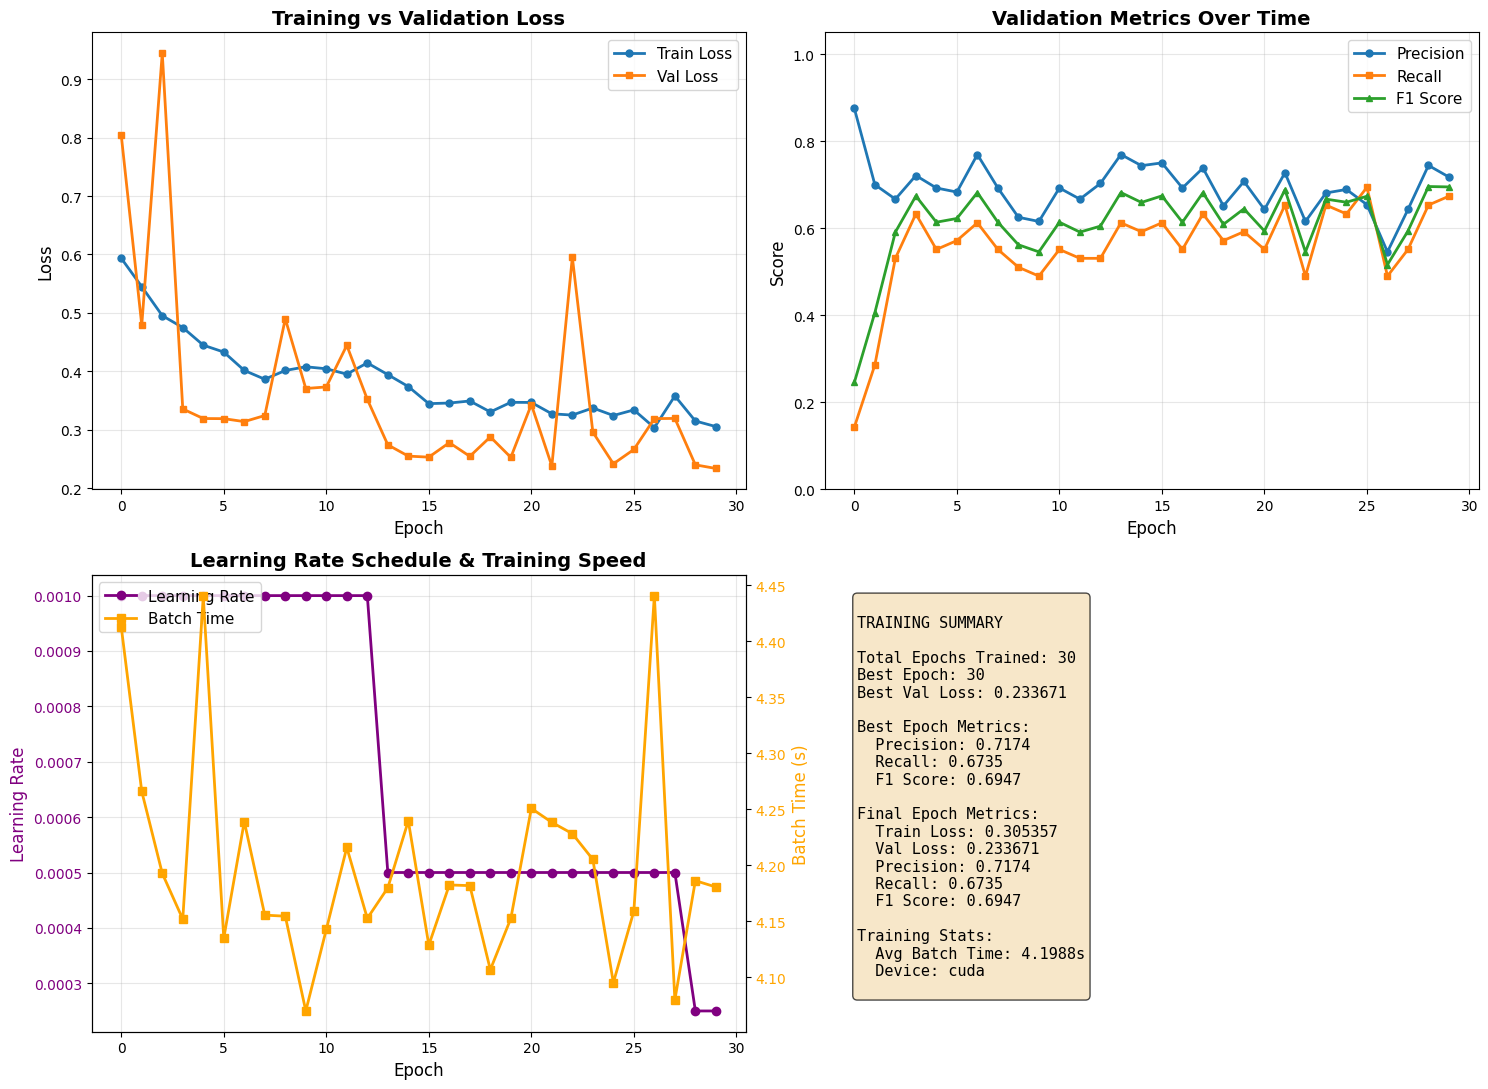


✓ Training history plotted successfully


In [19]:
# ============================================================================
# STEP 3 - PART 7: Plot Training History
# ============================================================================

print("\n" + "="*70)
print("PLOTTING TRAINING HISTORY")
print("="*70)

# Load training history
history_path = os.path.join(CHECKPOINT_DIR, 'training_history.json')
with open(history_path, 'r') as f:
    history = json.load(f)

# Create figure with subplots
fig, axes = plt.subplots(2, 2, figsize=(15, 11))

# Plot 1: Loss over epochs
ax = axes[0, 0]
ax.plot(history['train_loss'], label='Train Loss', marker='o', linewidth=2, markersize=5)
ax.plot(history['val_loss'], label='Val Loss', marker='s', linewidth=2, markersize=5)
ax.set_xlabel('Epoch', fontsize=12)
ax.set_ylabel('Loss', fontsize=12)
ax.set_title('Training vs Validation Loss', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)

# Plot 2: Validation Metrics
ax = axes[0, 1]
ax.plot(history['val_precision'], label='Precision', marker='o', linewidth=2, markersize=5)
ax.plot(history['val_recall'], label='Recall', marker='s', linewidth=2, markersize=5)
ax.plot(history['val_f1'], label='F1 Score', marker='^', linewidth=2, markersize=5)
ax.set_xlabel('Epoch', fontsize=12)
ax.set_ylabel('Score', fontsize=12)
ax.set_title('Validation Metrics Over Time', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
ax.set_ylim([0, 1.05])

# Plot 3: Learning Rate and Batch Time
ax = axes[1, 0]
ax2 = ax.twinx()

line1 = ax.plot(history['learning_rates'], marker='o', linewidth=2, color='purple', label='Learning Rate')
line2 = ax2.plot(history['batch_times'], marker='s', linewidth=2, color='orange', label='Batch Time')

ax.set_xlabel('Epoch', fontsize=12)
ax.set_ylabel('Learning Rate', fontsize=12, color='purple')
ax2.set_ylabel('Batch Time (s)', fontsize=12, color='orange')
ax.set_title('Learning Rate Schedule & Training Speed', fontsize=14, fontweight='bold')
ax.tick_params(axis='y', labelcolor='purple')
ax2.tick_params(axis='y', labelcolor='orange')
ax.grid(True, alpha=0.3)

# Combined legend
lines = line1 + line2
labels = [l.get_label() for l in lines]
ax.legend(lines, labels, loc='upper left', fontsize=11)

# Plot 4: Summary text
ax = axes[1, 1]
ax.axis('off')

best_epoch = np.argmin(history['val_loss'])
summary_text = f"""
TRAINING SUMMARY

Total Epochs Trained: {len(history['train_loss'])}
Best Epoch: {best_epoch + 1}
Best Val Loss: {history['val_loss'][best_epoch]:.6f}

Best Epoch Metrics:
  Precision: {history['val_precision'][best_epoch]:.4f}
  Recall: {history['val_recall'][best_epoch]:.4f}
  F1 Score: {history['val_f1'][best_epoch]:.4f}

Final Epoch Metrics:
  Train Loss: {history['train_loss'][-1]:.6f}
  Val Loss: {history['val_loss'][-1]:.6f}
  Precision: {history['val_precision'][-1]:.4f}
  Recall: {history['val_recall'][-1]:.4f}
  F1 Score: {history['val_f1'][-1]:.4f}

Training Stats:
  Avg Batch Time: {np.mean(history['batch_times']):.4f}s
  Device: {device}
"""

ax.text(0.05, 0.95, summary_text, fontsize=11, verticalalignment='top',
        family='monospace', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.7))

plt.tight_layout()
plt.savefig(os.path.join(CHECKPOINT_DIR, 'training_history.png'), dpi=150, bbox_inches='tight')
print(f"\n✓ Training history plot saved to: {os.path.join(CHECKPOINT_DIR, 'training_history.png')}")
plt.show()

print("\n✓ Training history plotted successfully")


In [20]:
# ============================================================================
# STEP 3 - PART 8: Evaluate Model on Test Set
# ============================================================================

print("\n" + "="*70)
print("EVALUATING MODEL ON TEST SET")
print("="*70)

model.eval()  # Set to evaluation mode

test_loss = 0.0
num_test_batches = 0
all_test_predictions = []
all_test_labels = []

print(f"\n[INFO] Running inference on test set...")

with torch.no_grad():
    pbar = tqdm(test_loader, desc="Testing")
    
    for images, labels in pbar:
        # Move to device
        images = images.to(device)
        labels = labels.to(device)
        
        # Forward pass
        outputs = model(images)
        
        # Calculate loss
        loss = criterion(outputs, labels)
        test_loss += loss.item()
        num_test_batches += 1
        
        # Store predictions and labels
        all_test_predictions.append(torch.sigmoid(outputs).cpu())
        all_test_labels.append(labels.cpu())
        
        pbar.set_postfix({'loss': f'{loss.item():.4f}'})

avg_test_loss = test_loss / num_test_batches

# Concatenate all batches
all_test_predictions = torch.cat(all_test_predictions, dim=0)
all_test_labels = torch.cat(all_test_labels, dim=0)

# Convert to binary predictions using threshold 0.5
test_pred_binary = (all_test_predictions > 0.5).float()

# Calculate metrics
tp = (test_pred_binary * all_test_labels).sum()
fp = (test_pred_binary * (1 - all_test_labels)).sum()
fn = ((1 - test_pred_binary) * all_test_labels).sum()

test_precision = tp / (tp + fp + 1e-8)
test_recall = tp / (tp + fn + 1e-8)
test_f1 = 2 * (test_precision * test_recall) / (test_precision + test_recall + 1e-8)

# Per-class metrics
print(f"\n" + "="*70)
print("TEST SET RESULTS")
print("="*70)

print(f"\nOverall Metrics:")
print(f"  Loss: {avg_test_loss:.6f}")
print(f"  Precision: {test_precision.item():.4f}")
print(f"  Recall: {test_recall.item():.4f}")
print(f"  F1 Score: {test_f1.item():.4f}")

# Per-class breakdown
print(f"\nPer-Class Metrics:")
print(f"{'Class':<20} {'Precision':<12} {'Recall':<12} {'F1 Score':<12}")
print(f"{'-'*56}")

for class_idx, class_name in enumerate(CLASS_NAMES):
    class_pred = test_pred_binary[:, class_idx]
    class_label = all_test_labels[:, class_idx]
    
    class_tp = (class_pred * class_label).sum()
    class_fp = (class_pred * (1 - class_label)).sum()
    class_fn = ((1 - class_pred) * class_label).sum()
    
    class_precision = class_tp / (class_tp + class_fp + 1e-8)
    class_recall = class_tp / (class_tp + class_fn + 1e-8)
    class_f1 = 2 * (class_precision * class_recall) / (class_precision + class_recall + 1e-8)
    
    print(f"{class_name:<20} {class_precision.item():<12.4f} {class_recall.item():<12.4f} {class_f1.item():<12.4f}")

print(f"\n✓ Test set evaluation complete")



EVALUATING MODEL ON TEST SET

[INFO] Running inference on test set...


Testing: 100%|██████████| 1/1 [00:01<00:00,  1.40s/it, loss=0.4491]


TEST SET RESULTS

Overall Metrics:
  Loss: 0.449109
  Precision: 0.7692
  Recall: 0.6452
  F1 Score: 0.7018

Per-Class Metrics:
Class                Precision    Recall       F1 Score    
--------------------------------------------------------
Sulfide Inclusion    0.6667       0.8000       0.7273      
Alumina Inclusion    0.8571       0.6000       0.7059      
Silicate Inclusion   1.0000       0.2500       0.4000      
Globular oxide Inclusion 0.7500       0.7500       0.7500      

✓ Test set evaluation complete


In [21]:
# ============================================================================
# STEP 3 - PART 9: Confusion Matrix and Detailed Analysis
# ============================================================================

from sklearn.metrics import multilabel_confusion_matrix, hamming_loss

print("\n" + "="*70)
print("DETAILED ANALYSIS AND CONFUSION MATRICES")
print("="*70)

# Convert to numpy
test_labels_np = all_test_labels.numpy()
test_pred_np = test_pred_binary.numpy()

# Calculate Hamming Loss (fraction of labels that are incorrectly predicted)
hamming = hamming_loss(test_labels_np, test_pred_np)
print(f"\nHamming Loss: {hamming:.4f}")
print(f"(Lower is better - fraction of incorrect labels)")

# Get multilabel confusion matrices
conf_matrices = multilabel_confusion_matrix(test_labels_np, test_pred_np)

print(f"\nConfusion Matrix per Class:")
print(f"{'Class':<20} {'TP':<6} {'FP':<6} {'FN':<6} {'TN':<6}")
print(f"{'-'*44}")

for class_idx, class_name in enumerate(CLASS_NAMES):
    tn, fp, fn, tp = conf_matrices[class_idx].ravel()
    print(f"{class_name:<20} {int(tp):<6} {int(fp):<6} {int(fn):<6} {int(tn):<6}")

# Accuracy per class
print(f"\nAccuracy per Class:")
for class_idx, class_name in enumerate(CLASS_NAMES):
    tn, fp, fn, tp = conf_matrices[class_idx].ravel()
    class_accuracy = (tp + tn) / (tp + tn + fp + fn)
    print(f"  {class_name}: {class_accuracy:.4f}")

# Subset accuracy (exact match)
exact_matches = (test_pred_np == test_labels_np).all(axis=1).sum()
subset_accuracy = exact_matches / len(test_labels_np)
print(f"\nSubset Accuracy (Exact Match): {subset_accuracy:.4f}")
print(f"  {int(exact_matches)}/{len(test_labels_np)} samples correctly classified")

print(f"\n✓ Detailed analysis complete")



DETAILED ANALYSIS AND CONFUSION MATRICES

Hamming Loss: 0.1771
(Lower is better - fraction of incorrect labels)

Confusion Matrix per Class:
Class                TP     FP     FN     TN    
--------------------------------------------
Sulfide Inclusion    4      2      1      17    
Alumina Inclusion    6      1      4      13    
Silicate Inclusion   1      0      3      20    
Globular oxide Inclusion 9      3      3      9     

Accuracy per Class:
  Sulfide Inclusion: 0.8750
  Alumina Inclusion: 0.7917
  Silicate Inclusion: 0.8750
  Globular oxide Inclusion: 0.7500

Subset Accuracy (Exact Match): 0.6250
  15/24 samples correctly classified

✓ Detailed analysis complete



VISUALIZING TEST PREDICTIONS

✓ Test predictions visualization saved to: ./checkpoints\test_predictions.png


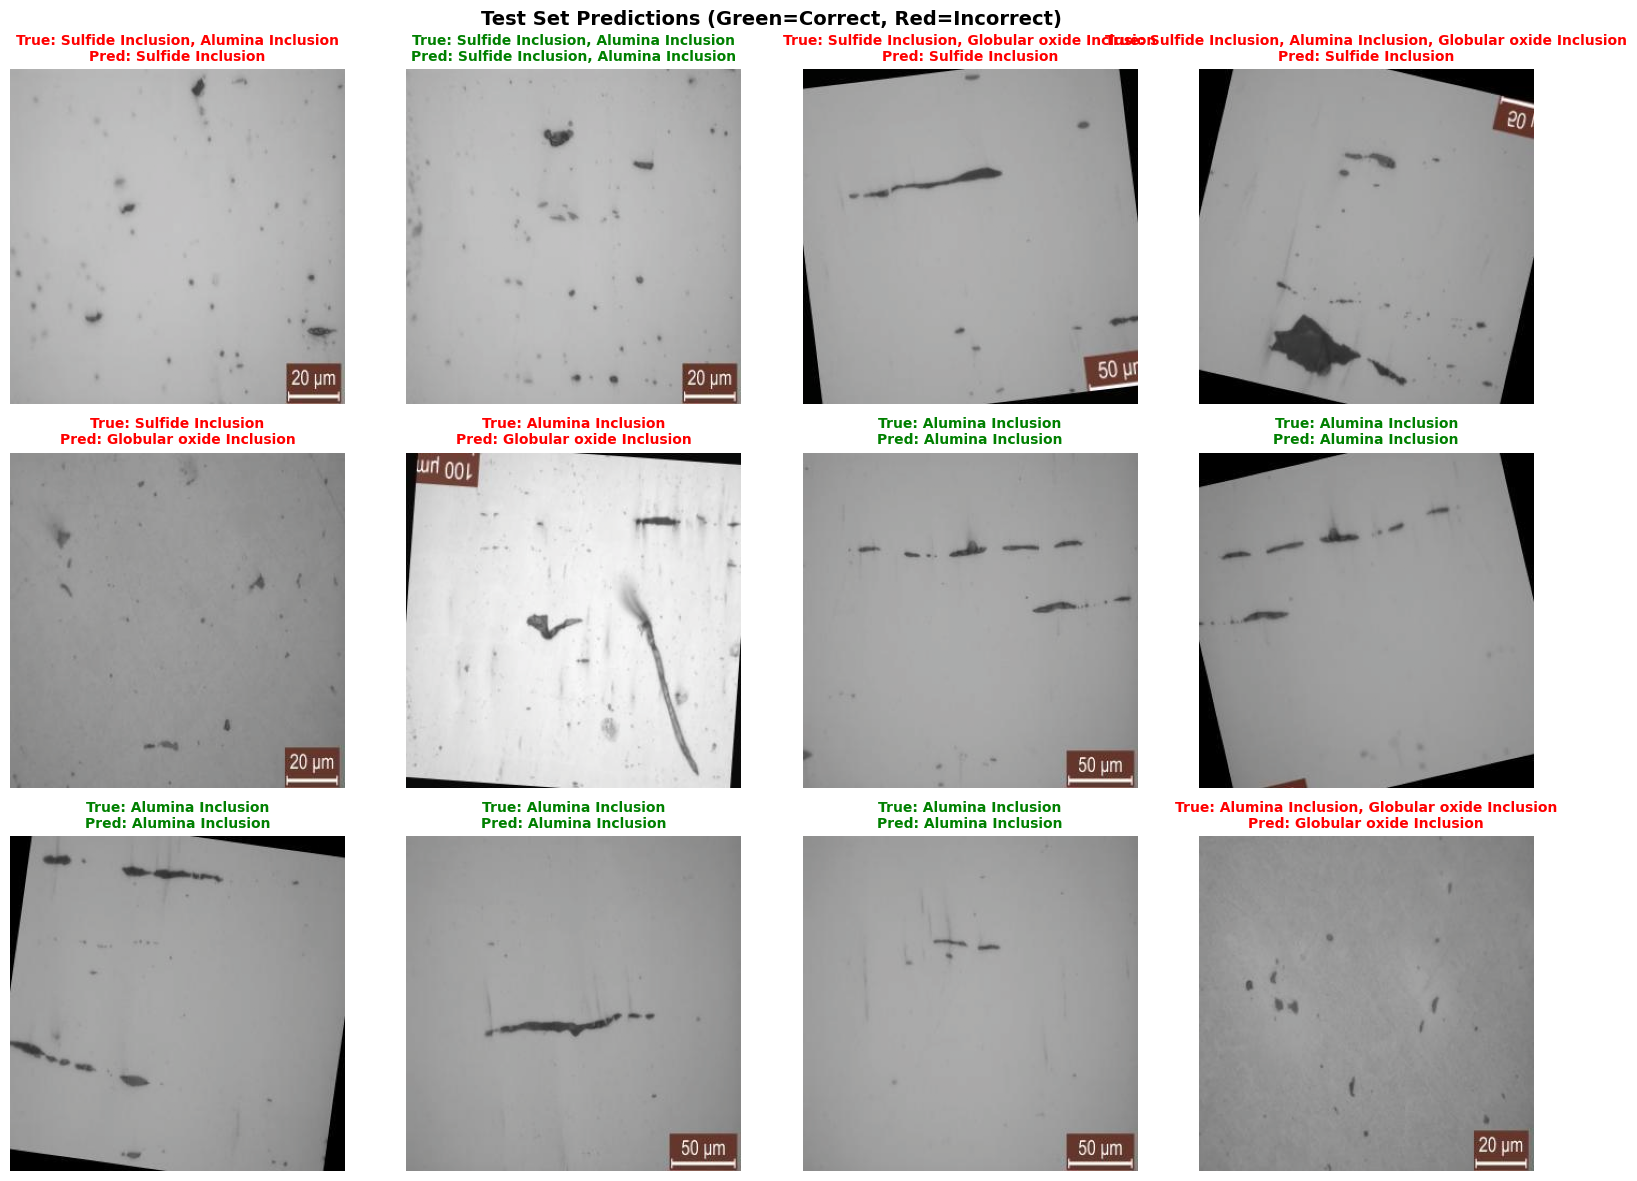


✓ Visualization complete


In [22]:
# ============================================================================
# STEP 3 - PART 10: Visualize Test Predictions
# ============================================================================

print("\n" + "="*70)
print("VISUALIZING TEST PREDICTIONS")
print("="*70)

def denormalize_image(tensor):
    """Convert normalized tensor back to [0, 1] for visualization"""
    inv_normalize = transforms.Compose([
        transforms.Normalize(
            mean=[-0.485/0.229, -0.456/0.224, -0.406/0.225],
            std=[1/0.229, 1/0.224, 1/0.225]
        )
    ])
    return inv_normalize(tensor)

# Get a test batch
test_images, test_labels_batch = next(iter(test_loader))
test_images = test_images.to(device)

# Get predictions
with torch.no_grad():
    test_outputs = model(test_images)
    test_probs = torch.sigmoid(test_outputs).cpu()
    test_preds = (test_probs > 0.5).float()

# Visualize
fig, axes = plt.subplots(3, 4, figsize=(16, 12))
axes = axes.flatten()

for idx in range(min(12, len(test_images))):
    ax = axes[idx]
    
    # Denormalize image
    img = denormalize_image(test_images[idx].cpu())
    img_np = img.numpy().transpose(1, 2, 0)
    img_np = np.clip(img_np, 0, 1)
    
    # Get predictions and labels
    pred_vector = test_preds[idx].numpy()
    label_vector = test_labels_batch[idx].numpy()
    
    # Get class names
    pred_classes = [CLASS_NAMES[i] for i in range(len(CLASS_NAMES)) if pred_vector[i] == 1]
    true_classes = [CLASS_NAMES[i] for i in range(len(CLASS_NAMES)) if label_vector[i] == 1]
    
    # Plot
    ax.imshow(img_np)
    
    # Title with predictions
    title_text = f"True: {', '.join(true_classes) if true_classes else 'None'}\n"
    title_text += f"Pred: {', '.join(pred_classes) if pred_classes else 'None'}"
    
    # Color title based on correctness
    is_correct = (pred_vector == label_vector).all()
    title_color = 'green' if is_correct else 'red'
    
    ax.set_title(title_text, fontsize=10, fontweight='bold', color=title_color)
    ax.axis('off')

plt.suptitle('Test Set Predictions (Green=Correct, Red=Incorrect)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(CHECKPOINT_DIR, 'test_predictions.png'), dpi=150, bbox_inches='tight')
print(f"\n✓ Test predictions visualization saved to: {os.path.join(CHECKPOINT_DIR, 'test_predictions.png')}")
plt.show()

print("\n✓ Visualization complete")


In [23]:
# ============================================================================
# STEP 3 - PART 11: Save Final Results Summary
# ============================================================================

print("\n" + "="*70)
print("SAVING FINAL RESULTS")
print("="*70)

# Create results summary
results_summary = {
    'model_info': {
        'architecture': 'ResNet50 + Custom Classifier',
        'num_classes': NUM_CLASSES,
        'classes': CLASS_NAMES,
        'total_parameters': int(total_params),
        'trainable_parameters': int(trainable_params)
    },
    'training_info': {
        'total_epochs': len(history['train_loss']),
        'best_epoch': int(best_epoch + 1),
        'device': str(device),
        'batch_size': BATCH_SIZE,
        'learning_rate': learning_rate
    },
    'best_validation_metrics': {
        'epoch': int(best_epoch + 1),
        'loss': float(history['val_loss'][best_epoch]),
        'precision': float(history['val_precision'][best_epoch]),
        'recall': float(history['val_recall'][best_epoch]),
        'f1_score': float(history['val_f1'][best_epoch])
    },
    'test_metrics': {
        'loss': float(avg_test_loss),
        'precision': float(test_precision.item()),
        'recall': float(test_recall.item()),
        'f1_score': float(test_f1.item()),
        'hamming_loss': float(hamming),
        'subset_accuracy': float(subset_accuracy)
    },
    'per_class_test_metrics': {}
}

# Add per-class metrics
for class_idx, class_name in enumerate(CLASS_NAMES):
    class_pred = test_pred_binary[:, class_idx]
    class_label = all_test_labels[:, class_idx]
    
    class_tp = (class_pred * class_label).sum()
    class_fp = (class_pred * (1 - class_label)).sum()
    class_fn = ((1 - class_pred) * class_label).sum()
    
    class_precision = class_tp / (class_tp + class_fp + 1e-8)
    class_recall = class_tp / (class_tp + class_fn + 1e-8)
    class_f1 = 2 * (class_precision * class_recall) / (class_precision + class_recall + 1e-8)
    
    results_summary['per_class_test_metrics'][class_name] = {
        'precision': float(class_precision.item()),
        'recall': float(class_recall.item()),
        'f1_score': float(class_f1.item())
    }

# Save as JSON
results_path = os.path.join(CHECKPOINT_DIR, 'results_summary.json')
with open(results_path, 'w') as f:
    json.dump(results_summary, f, indent=4)

print(f"\n✓ Results summary saved to: {results_path}")

# Print summary
print(f"\n" + "="*70)
print("FINAL RESULTS SUMMARY")
print("="*70)
print(json.dumps(results_summary, indent=2))

print(f"\n{'='*70}")
print("ALL STEPS COMPLETE!")
print(f"{'='*70}")
print(f"\nCheckpoint Directory: {CHECKPOINT_DIR}")
print(f"  - best_model.pth (best trained model)")
print(f"  - final_model.pth (final model)")
print(f"  - training_history.json (training metrics)")
print(f"  - training_history.png (training plots)")
print(f"  - test_predictions.png (test predictions)")
print(f"  - results_summary.json (final results)")



SAVING FINAL RESULTS

✓ Results summary saved to: ./checkpoints\results_summary.json

FINAL RESULTS SUMMARY
{
  "model_info": {
    "architecture": "ResNet50 + Custom Classifier",
    "num_classes": 4,
    "classes": [
      "Sulfide Inclusion",
      "Alumina Inclusion",
      "Silicate Inclusion",
      "Globular oxide Inclusion"
    ],
    "total_parameters": 24623300,
    "trainable_parameters": 24623300
  },
  "training_info": {
    "total_epochs": 30,
    "best_epoch": 30,
    "device": "cuda",
    "batch_size": 32,
    "learning_rate": 0.001
  },
  "best_validation_metrics": {
    "epoch": 30,
    "loss": 0.23367063840851188,
    "precision": 0.717391312122345,
    "recall": 0.6734693646430969,
    "f1_score": 0.6947368383407593
  },
  "test_metrics": {
    "loss": 0.4491090774536133,
    "precision": 0.7692307829856873,
    "recall": 0.6451612710952759,
    "f1_score": 0.7017543911933899,
    "hamming_loss": 0.17708333333333334,
    "subset_accuracy": 0.625
  },
  "per_class_t

In [24]:
# ============================================================================
# STEP 4 - PART 1: Single Image Inference (with actual label shown)
# ============================================================================

import os
from PIL import Image

def predict_single_image_with_truth(image_path, test_dataset, model, device, class_names, threshold=0.5):
    """
    Predict inclusions on a single image and display both predicted and true types.
    """
    # Try to look up the actual label from the dataset by file name
    filename = os.path.basename(image_path)
    # Search in test_dataset
    true_label_vector = test_dataset.image_labels.get(filename, None)
    actual_types = [class_names[i] for i, v in enumerate(true_label_vector) if v] if true_label_vector else ["Unknown"]

    # Preprocess
    transform = transforms.Compose([
        transforms.Resize((312, 312)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])
    image = Image.open(image_path).convert('RGB')
    image_tensor = transform(image).unsqueeze(0).to(device)
    
    # Predict
    model.eval()
    with torch.no_grad():
        logits = model(image_tensor)
        probs = torch.sigmoid(logits).cpu().squeeze().numpy()
    
    pred_types = [class_names[i] for i, p in enumerate(probs) if p > threshold]

    print(f"\n{'='*60}")
    print(f"Predicted types: {', '.join(pred_types) if pred_types else 'None'}")
    print(f"Actual types   : {', '.join(actual_types) if actual_types else 'None'}")
    print(f"{'='*60}")

    # Optionally return details for additional use
    return {
        "image": image_path,
        "predicted_types": pred_types,
        "actual_types": actual_types,
        "probabilities": probs.tolist()
    }

# Example use on an image from your test set:
sample_image_name = os.listdir(os.path.join(DATASET_ROOT, 'test', CLASS_NAMES[0]))[0]
sample_image_path = os.path.join(DATASET_ROOT, 'test', CLASS_NAMES[0], sample_image_name)
predict_single_image_with_truth(sample_image_path, test_dataset, model, device, CLASS_NAMES, threshold=0.5)



Predicted types: Sulfide Inclusion
Actual types   : Sulfide Inclusion, Alumina Inclusion


{'image': './inclusion_dataset_multilabel\\test\\Sulfide Inclusion\\0-3-200x0026_jpg.rf.2ec64b8153751b675d32943690bb79e1.jpg',
 'predicted_types': ['Sulfide Inclusion'],
 'actual_types': ['Sulfide Inclusion', 'Alumina Inclusion'],
 'probabilities': [0.5504517555236816,
  0.49959489703178406,
  0.1684204488992691,
  0.21084299683570862]}

In [25]:
# ============================================================================
# STEP 4 - PART 2: Batch Inference - Actual vs Predicted Types
# ============================================================================

batch = next(iter(test_loader))
test_imgs, test_targets = batch  # images, true labels
test_imgs = test_imgs.to(device)

model.eval()
with torch.no_grad():
    out_logits = model(test_imgs)
    out_probs = torch.sigmoid(out_logits).cpu().numpy()
    out_pred_vectors = (out_probs > 0.5).astype(int)

for idx in range(min(10, len(test_imgs))):
    true_types = [CLASS_NAMES[i] for i, v in enumerate(test_targets[idx].numpy()) if v]
    pred_types = [CLASS_NAMES[i] for i, v in enumerate(out_pred_vectors[idx]) if v]
    
    print(f"Sample {idx + 1}:")
    print(f"  TRUE      : {', '.join(true_types) if true_types else 'None'}")
    print(f"  PREDICTED : {', '.join(pred_types) if pred_types else 'None'}")
    print('-' * 40)


Sample 1:
  TRUE      : Sulfide Inclusion, Alumina Inclusion
  PREDICTED : Sulfide Inclusion
----------------------------------------
Sample 2:
  TRUE      : Sulfide Inclusion, Alumina Inclusion
  PREDICTED : Sulfide Inclusion, Alumina Inclusion
----------------------------------------
Sample 3:
  TRUE      : Sulfide Inclusion, Globular oxide Inclusion
  PREDICTED : Sulfide Inclusion
----------------------------------------
Sample 4:
  TRUE      : Sulfide Inclusion, Alumina Inclusion, Globular oxide Inclusion
  PREDICTED : Sulfide Inclusion
----------------------------------------
Sample 5:
  TRUE      : Sulfide Inclusion
  PREDICTED : Globular oxide Inclusion
----------------------------------------
Sample 6:
  TRUE      : Alumina Inclusion
  PREDICTED : Globular oxide Inclusion
----------------------------------------
Sample 7:
  TRUE      : Alumina Inclusion
  PREDICTED : Alumina Inclusion
----------------------------------------
Sample 8:
  TRUE      : Alumina Inclusion
  PREDICTED

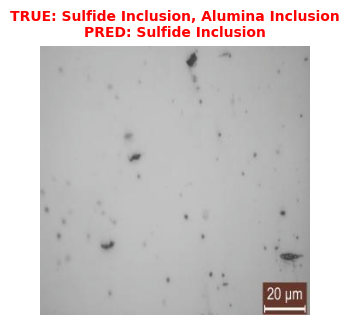

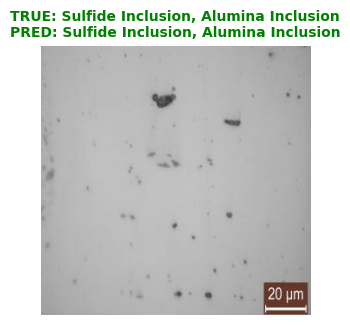

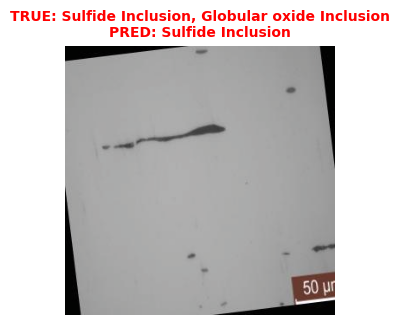

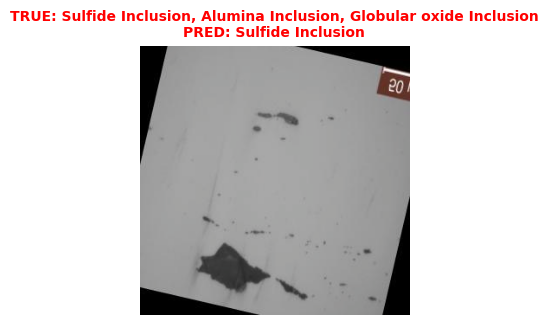

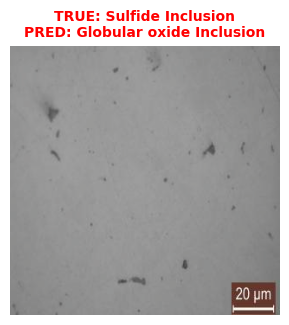

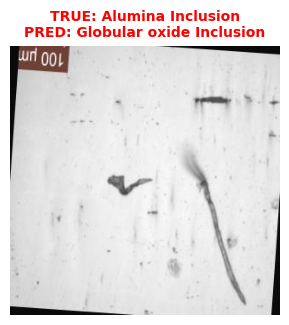

In [26]:
# ============================================================================
# STEP 4 - PART 3: Visualize Ground truth and Prediction per Image
# ============================================================================

def denormalize_image(tensor):
    inv_normalize = transforms.Compose([
        transforms.Normalize(
            mean=[-0.485 / 0.229, -0.456 / 0.224, -0.406 / 0.225],
            std=[1 / 0.229, 1 / 0.224, 1 / 0.225]
        )
    ])
    return inv_normalize(tensor)

import matplotlib.pyplot as plt
import numpy as np

# Visualize first few images from a test batch
for idx in range(min(6, len(test_imgs))):
    img_dn = denormalize_image(test_imgs[idx].cpu())
    img_np = img_dn.numpy().transpose(1, 2, 0)
    img_np = np.clip(img_np, 0, 1)
    
    true_types = [CLASS_NAMES[i] for i, v in enumerate(test_targets[idx].numpy()) if v]
    pred_types = [CLASS_NAMES[i] for i, v in enumerate(out_pred_vectors[idx]) if v]
    correct = set(true_types) == set(pred_types)
    
    plt.figure(figsize=(3.5, 3.5))
    plt.imshow(img_np)
    plt.axis('off')
    plt.title(f"TRUE: {', '.join(true_types)}\nPRED: {', '.join(pred_types)}",
        fontsize=10,
        color=('green' if correct else 'red'),
        fontweight='bold')
    plt.show()


In [27]:
# ============================================================================
# STEP 4 - PART 4: Save Full Batch Results to CSV
# ============================================================================

import pandas as pd

row_data = []
for idx in range(len(test_imgs)):
    true_types = [CLASS_NAMES[i] for i, v in enumerate(test_targets[idx].numpy()) if v]
    pred_types = [CLASS_NAMES[i] for i, v in enumerate(out_pred_vectors[idx]) if v]
    row_data.append({
        'Image Index': idx,
        'Actual Types': ', '.join(true_types),
        'Predicted Types': ', '.join(pred_types)
    })

df_out = pd.DataFrame(row_data)
df_out.to_csv(os.path.join(CHECKPOINT_DIR, 'test_batch_predictions.csv'), index=False)
print("✓ Test batch predictions (with true types) saved to:", os.path.join(CHECKPOINT_DIR, 'test_batch_predictions.csv'))


✓ Test batch predictions (with true types) saved to: ./checkpoints\test_batch_predictions.csv
